Building a Router based Agentic Workflow - Financial Operations Assistant

In [2]:
!pip install -q langgraph langchain langchain-google-genai google-search-results

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 3.9 MB/s eta 0:00:00


In [3]:
import os
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_google_genai import ChatGoogleGenerativeAI
from serpapi import GoogleSearch

In [4]:
os.environ['GOOGLE_API_KEY']=''
os.environ['SERP_API_KEY']=''

In [5]:
llm=ChatGoogleGenerativeAI(
    model='gemini-2.5-flash'
)

In [6]:
class FinanceState(TypedDict):
  query:str
  route:str
  output:str

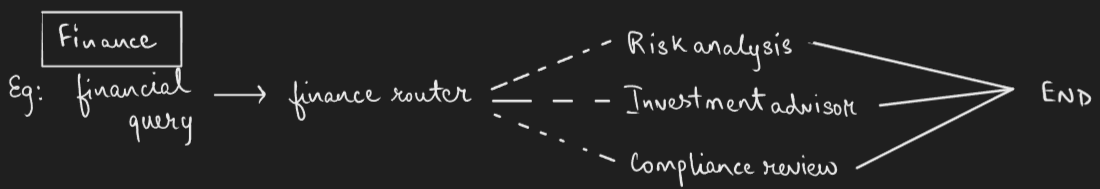

In [7]:
#defining the router node - finance router
def finance_router(state:FinanceState):

  query=state['query'] #financial query

  prompt=f"""
  You are a financial operations router.

  Categorize the query into one of the followin categories:
  - risk_analysis
  - investment_advisory
  - compliance_review

  Query:
  {query}

  Return only the category name."""

  response=llm.invoke(prompt)

  return {
      "route":response.content.strip().lower()
  }

In [8]:
#Creating the next node - risk analysis node
#When building a similar node next time - incorporate real-time market context to improve the response generated
def risk_analysis(state:FinanceState):

  query=state['query']

  prompt=f"""
  Analyze the financial risks

  Query:{query}

  Include:
  - Key Risks
  - Market Exposure
  - Mitigation strategies"""

  response=llm.invoke(prompt)

  return {
      "output":response.content
  }

In [9]:
#Creating the next node - investment advisory
def investment_advisory(state:FinanceState):

  query=state['query']

  prompt=f"""
  Provide investment advisory insights.
  Query:{query}

  Include:
  - Investment opportunities
  - Diversification ideas
  - Strategic recommendations
  """

  response=llm.invoke(prompt)

  return {
      "output":response.content
  }

In [10]:
#Creating the next node - compliance review
def compliance_review(state:FinanceState):

  query=state['query']

  prompt=f"""
  Perform compliance assessment.
  Query:{query}

  Include:
  - regulatory concerns
  - policy violations
  - audit recommendation
  """

  response=llm.invoke(prompt)

  return {
      "output":response.content
  }

In [11]:
#This is where we mention the routing conditions
def finance_route_decision(state:FinanceState):
  route=state['route']

  if "risk" in route:
    return "risk_analysis"

  elif "investment" in route:
    return "investment_advisory"

  else:
    return "compliance_review"

In [12]:
graph=StateGraph(FinanceState)

graph.add_node("finance_router",finance_router)
graph.add_node('risk_analysis',risk_analysis)
graph.add_node('investment_advisory',investment_advisory)
graph.add_node('compliance_review',compliance_review)

graph.set_entry_point("finance_router")

graph.add_conditional_edges(
    "finance_router",finance_route_decision,
    {
        "risk_analysis":"risk_analysis",
        "investment_advisory":"investment_advisory",
        "compliance_review":"compliance_review"
    }
)

graph.add_edge("risk_analysis",END)
graph.add_edge("investment_advisory",END)
graph.add_edge("compliance_review",END)

financial_workflow=graph.compile()

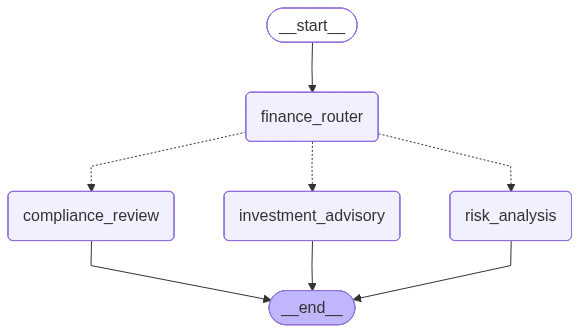

In [13]:
financial_workflow

In [15]:
response=financial_workflow.invoke(
    {
        "query":"High inflation and declining equity portfolio exposure in emerging markets"
    }
)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 46.973575917s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT

In [ ]:
response["output"]